In [1]:
import pandas as pd
import matplotlib.pyplot as plt

--- Table Info ---
<class 'pandas.DataFrame'>
RangeIndex: 109775 entries, 0 to 109774
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   icd_code     109775 non-null  str  
 1   icd_version  109775 non-null  int64
 2   long_title   109775 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.5 MB

--- First 5 Rows ---


,icd_code,icd_version,long_title
0,0090,9,"Infectious colitis, enteritis, and gastroenter..."
1,01160,9,"Tuberculous pneumonia [any form], unspecified"
2,01186,9,"Other specified pulmonary tuberculosis, tuberc..."
3,01200,9,"Tuberculous pleurisy, unspecified"
4,01236,9,"Tuberculous laryngitis, tubercle bacilli not f..."



--- Distribution Stats ---
count    2852.000000
mean       38.490533
std       141.626223
min         1.000000
25%         5.000000
50%        10.000000
75%        25.000000
max      3346.000000
Name: count, dtype: float64


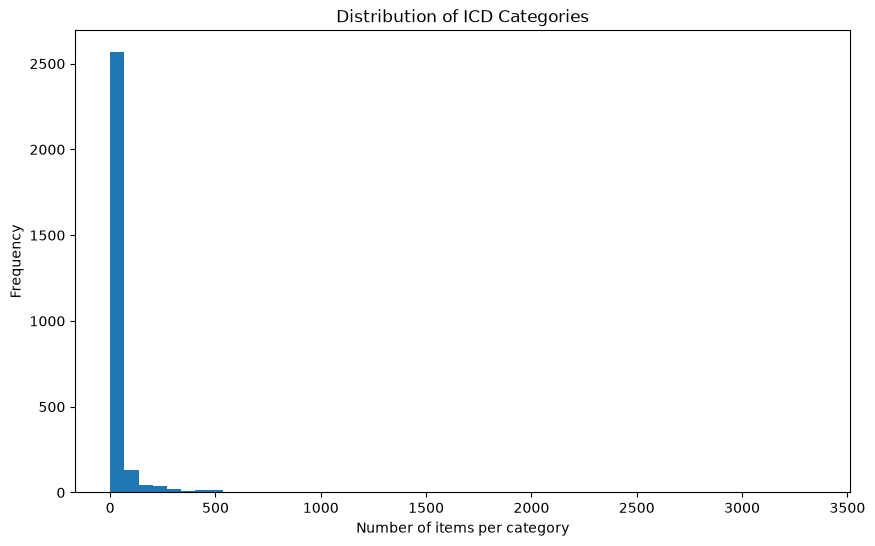


--- Top 10 Heaviest Categories (Check these for sub-chunking) ---
category
S82    3346
S52    3034
S72    2660
S62    2230
S42    1644
S92    1631
S63    1333
M84    1121
S32    1024
T23     945
Name: count, dtype: int64


In [5]:
# 1. Load the data
df = pd.read_csv('/Users/adeeb/enterprise-ai-analyst/data/mimic/mimic-iv-clinical-database-demo-2.2/hosp/d_icd_diagnoses.csv.gz')

# 2. Inspect the structure
print("--- Table Info ---")
df.info()
print("\n--- First 5 Rows ---")
display(df.head())

# 3. Calculate the potential chunking key (ICD Category)
# We assume 'icd_code' is the column name containing the codes
df['category'] = df['icd_code'].str[:3]

# 4. Statistical Analysis
category_counts = df['category'].value_counts()
print("\n--- Distribution Stats ---")
print(category_counts.describe())

# 5. Visualization to identify "Oversized" chunks
plt.figure(figsize=(10, 6))
category_counts.plot(kind='hist', bins=50, title='Distribution of ICD Categories')
plt.xlabel('Number of items per category')
plt.ylabel('Frequency')
plt.show()

# 6. Check the largest categories
print("\n--- Top 10 Heaviest Categories (Check these for sub-chunking) ---")
print(category_counts.head(10))

In [6]:
def get_adaptive_chunk_key(icd_code):
    # Standard prefix
    prefix = icd_code[:3]
    
    # Identify "Heavy" categories that need sub-splitting
    # These codes (S82, S52, etc.) represent fracture sites, which 
    # are notoriously dense in ICD data.
    heavy_categories = {'S82', 'S52', 'S72', 'S62', 'S42', 'S92', 'S63', 'M84', 'S32', 'T23'}
    
    if prefix in heavy_categories:
        # Sub-split using the 4th character or full code
        # This keeps the chunk size small and semantically coherent
        return icd_code[:4] 
    
    return prefix

# Apply this to your dataframe
df['chunk_key'] = df['icd_code'].apply(get_adaptive_chunk_key)

In [8]:
def get_refined_chunk_key(icd_code):
    # 1. Start with the category
    prefix = icd_code[:3]
    
    # 2. Check for known "Heavy" categories from your analysis
    if prefix in ['S82', 'S52', 'S72', 'S62', 'S42', 'S92', 'S63', 'M84', 'S32', 'T23']:
        # Use the 4th character to group into specific anatomical subsets
        # This keeps Patella (S820) separate from Tibial (S821)
        return icd_code[:4]
    
    # 3. Fallback for lighter categories
    return prefix

Original max chunk size: 3346
New max chunk size: 811

--- Check S82 Status ---


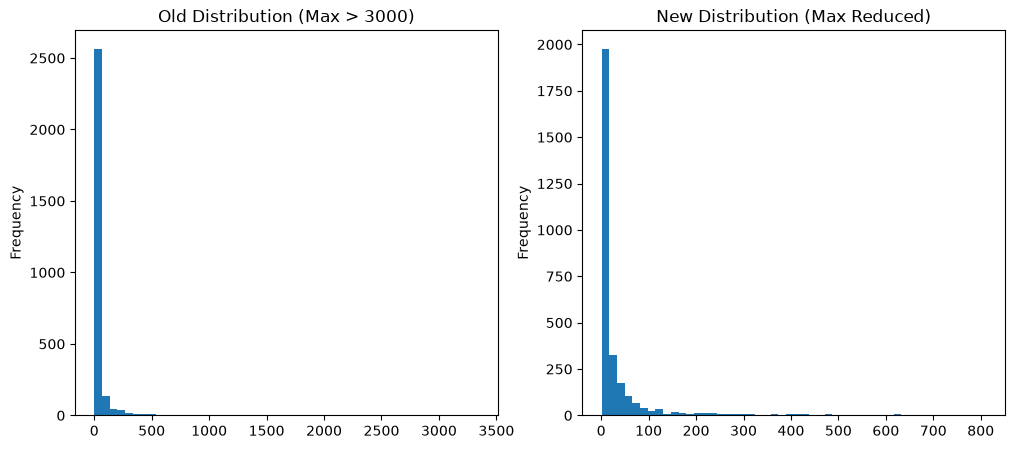

In [9]:
# 1. Apply your new logic
df['new_chunk_key'] = df['icd_code'].apply(get_refined_chunk_key)

# 2. Compare the distributions
old_dist = df['icd_code'].str[:3].value_counts()
new_dist = df['new_chunk_key'].value_counts()

print(f"Original max chunk size: {old_dist.max()}")
print(f"New max chunk size: {new_dist.max()}")

# 3. Verify specifically if the 'Heavy' ones were split
# Check if S82 is gone and replaced by S820, S821, etc.
print("\n--- Check S82 Status ---")
if 'S82' in new_dist.index:
    print("Warning: S82 still exists! Check your logic.")
else:
    print("Success: S82 has been partitioned.")
    print(f"New S82 sub-groups: {new_dist.filter(like='S82').index.tolist()}")

# 4. Visualization of the improvement
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
old_dist.plot(kind='hist', bins=50, title='Old Distribution (Max > 3000)')
plt.subplot(1, 2, 2)
new_dist.plot(kind='hist', bins=50, title='New Distribution (Max Reduced)')
plt.show()

In [10]:
# --- Cell: Build adaptive chunks (replaces your fixed-4-char attempt) ---
MAX_CHUNK_SIZE = 40

def build_chunks(df, code_col='icd_code', version_col='icd_version', max_size=MAX_CHUNK_SIZE):
    chunks = {}
    def recurse(sub_df, prefix_len, version):
        if len(sub_df) <= max_size or prefix_len >= sub_df[code_col].str.len().max():
            key = f"{version}_{sub_df[code_col].iloc[0][:prefix_len] if prefix_len else 'ALL'}"
            chunks[key] = sub_df
            return
        sub_df = sub_df.copy()
        sub_df['_key'] = sub_df[code_col].str[:prefix_len]
        for _, group in sub_df.groupby('_key'):
            recurse(group.drop(columns='_key'), prefix_len + 1, version)
    for version, vdf in df.groupby(version_col):
        recurse(vdf, 3, version)
    return chunks

chunks = build_chunks(df)
print(f"Total chunks: {len(chunks)}")

Total chunks: 10595


In [11]:
# --- Cell: Validate the result ---
sizes = pd.Series({k: len(v) for k, v in chunks.items()})
print(sizes.describe())
print(f"Max chunk size: {sizes.max()}")
print(f"Chunks over {MAX_CHUNK_SIZE}: {(sizes > MAX_CHUNK_SIZE).sum()}")  # sanity check, should be 0

# specifically re-check S82
s82_chunks = {k: v for k, v in chunks.items() if k.startswith('10_S82')}
print(f"\nS82 split into {len(s82_chunks)} chunks, sizes: {[len(v) for v in s82_chunks.values()]}")

count    10595.000000
mean        10.361019
std          8.835801
min          1.000000
25%          4.000000
50%          8.000000
75%         13.000000
max         40.000000
dtype: float64
Max chunk size: 40
Chunks over 40: 0

S82 split into 238 chunks, sizes: [1, 1, 1, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 1, 1, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 22, 1, 17, 17, 17, 1, 1, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 1, 1, 17, 17, 17, 22, 1, 17, 17, 17, 1, 1, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 1, 17, 17, 17, 17, 17, 17, 1, 17, 17, 17, 17, 1

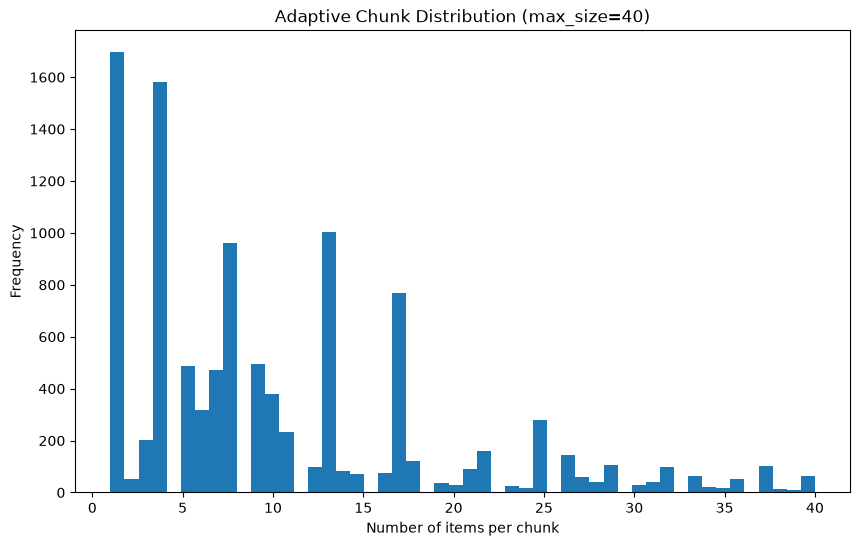

In [12]:
# --- Cell: Visualize new distribution ---
plt.figure(figsize=(10, 6))
sizes.plot(kind='hist', bins=50, title=f'Adaptive Chunk Distribution (max_size={MAX_CHUNK_SIZE})')
plt.xlabel('Number of items per chunk')
plt.ylabel('Frequency')
plt.show()

In [13]:
def merge_small_chunks(chunks, min_size=10, max_size=40):
    from collections import defaultdict
    # group chunk keys by their parent (version + first 3 chars) so we only merge within-family
    families = defaultdict(list)
    for key, df_chunk in chunks.items():
        parent = "_".join(key.split("_")[:2])[:6]  # crude family grouping, tune as needed
        families[parent].append((key, df_chunk))

    merged = {}
    for parent, items in families.items():
        items.sort(key=lambda x: len(x[1]))  # smallest first
        buffer = []
        buffer_size = 0
        merge_idx = 0
        for key, df_chunk in items:
            if len(df_chunk) >= min_size:
                merged[key] = df_chunk  # already fine on its own
                continue
            buffer.append(df_chunk)
            buffer_size += len(df_chunk)
            if buffer_size >= min_size:
                merged[f"{parent}_merged_{merge_idx}"] = pd.concat(buffer)
                buffer, buffer_size = [], 0
                merge_idx += 1
        if buffer:  # leftover small remainder
            merged[f"{parent}_merged_{merge_idx}"] = pd.concat(buffer)
    return merged

In [19]:
# --- Cell: Merge small chunks ---
merged_chunks = merge_small_chunks(chunks, min_size=10, max_size=40)
print(f"Before merge: {len(chunks)} chunks")
print(f"After merge:  {len(merged_chunks)} chunks")

sizes_merged = pd.Series({k: len(v) for k, v in merged_chunks.items()})
print(sizes_merged.describe())
print(f"Chunks under 5 rows: {(sizes_merged < 5).sum()}")
print(f"Chunks over 40 rows: {(sizes_merged > 40).sum()}")

Before merge: 10595 chunks
After merge:  7848 chunks
count    7848.000000
mean       13.987640
std         8.517569
min         1.000000
25%         8.000000
50%        13.000000
75%        17.000000
max        40.000000
dtype: float64
Chunks under 5 rows: 973
Chunks over 40 rows: 0


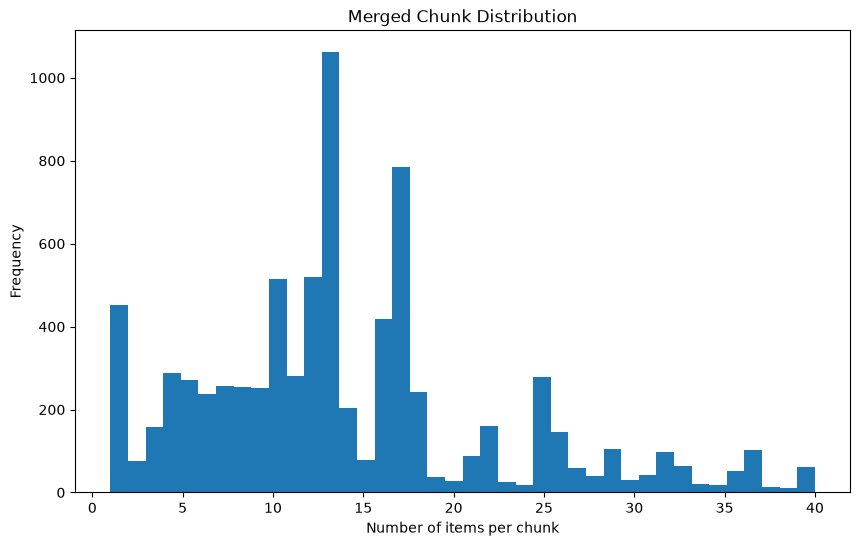

In [20]:
# --- Cell: Visualize merged distribution ---
plt.figure(figsize=(10, 6))
sizes_merged.plot(kind='hist', bins=40, title='Merged Chunk Distribution')
plt.xlabel('Number of items per chunk')
plt.ylabel('Frequency')
plt.show()

In [21]:
# --- Cell: Eyeball a few merged chunks ---
merged_keys = [k for k in merged_chunks if 'merged' in k]
print(f"Total merged (combined) chunks: {len(merged_keys)}")

for k in merged_keys[:5]:
    print(f"\n--- {k} ({len(merged_chunks[k])} rows) ---")
    print(merged_chunks[k]['long_title'].tolist())

Total merged (combined) chunks: 3516

--- 9_0010_merged_0 (3 rows) ---
['Cholera due to vibrio cholerae', 'Cholera, unspecified', 'Cholera due to vibrio cholerae el tor']

--- 9_0023_merged_0 (5 rows) ---
['Paratyphoid fever C', 'Paratyphoid fever, unspecified', 'Paratyphoid fever A', 'Typhoid fever', 'Paratyphoid fever B']

--- 9_0041_merged_0 (6 rows) ---
['Shigella flexneri', 'Other specified shigella infections', 'Shigellosis, unspecified', 'Shigella dysenteriae', 'Shigella sonnei', 'Shigella boydii']

--- 9_0052_merged_0 (8 rows) ---
['Food poisoning due to Clostridium perfringens (C. welchii)', 'Botulism food poisoning', 'Other bacterial food poisoning', 'Food poisoning due to other Clostridia', 'Staphylococcal food poisoning', 'Food poisoning, unspecified', 'Food poisoning due to Vibrio parahaemolyticus', 'Food poisoning due to Vibrio vulnificus']

--- 9_0063_merged_0 (9 rows) ---
['Amebic liver abscess', 'Amebic brain abscess', 'Acute amebic dysentery without mention of abscess

In [22]:
small_remaining = {k: v for k, v in merged_chunks.items() if len(v) < 5}
print(f"Still small: {len(small_remaining)}")

# sample a few and look at their neighbors
for k in list(small_remaining.keys())[:5]:
    print(f"\n{k}: {merged_chunks[k]['long_title'].tolist()}")

Still small: 973

9_0010_merged_0: ['Cholera due to vibrio cholerae', 'Cholera, unspecified', 'Cholera due to vibrio cholerae el tor']

9_0090_merged_0: ['Infectious colitis, enteritis, and gastroenteritis', 'Diarrhea of presumed infectious origin', 'Colitis, enteritis, and gastroenteritis of presumed infectious origin', 'Infectious diarrhea']

9_024_merged_0: ['Glanders']

9_025_merged_0: ['Melioidosis']

9_0269_merged_0: ['Unspecified rat-bite fever', 'Streptobacillary fever', 'Spirillary fever']


In [23]:
def merge_small_chunks_v2(chunks, min_size=10, max_size=40):
    from collections import defaultdict
    families = defaultdict(list)
    for key, df_chunk in chunks.items():
        version = df_chunk['icd_version'].iloc[0]
        root_category = df_chunk['icd_code'].iloc[0][:3]  # always 3-char root, reliable
        families[(version, root_category)].append((key, df_chunk))
    # ... rest of merge logic unchanged, just using this cleaner family key

In [24]:
# --- Cell: Merge small chunks ---
merged_chunks = merge_small_chunks_v2(chunks, min_size=10, max_size=40)
print(f"Before merge: {len(chunks)} chunks")
print(f"After merge:  {len(merged_chunks)} chunks")

sizes_merged = pd.Series({k: len(v) for k, v in merged_chunks.items()})
print(sizes_merged.describe())
print(f"Chunks under 5 rows: {(sizes_merged < 5).sum()}")
print(f"Chunks over 40 rows: {(sizes_merged > 40).sum()}")

Before merge: 10595 chunks


TypeError: object of type 'NoneType' has no len()

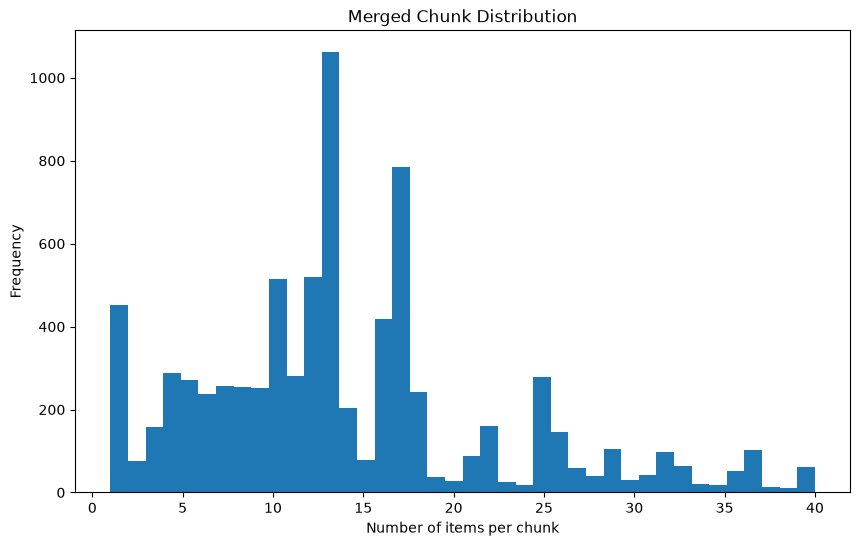

In [25]:
# --- Cell: Visualize merged distribution ---
plt.figure(figsize=(10, 6))
sizes_merged.plot(kind='hist', bins=40, title='Merged Chunk Distribution')
plt.xlabel('Number of items per chunk')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# --- Cell: Eyeball a few merged chunks ---
merged_keys = [k for k in merged_chunks if 'merged' in k]
print(f"Total merged (combined) chunks: {len(merged_keys)}")

for k in merged_keys[:5]:
    print(f"\n--- {k} ({len(merged_chunks[k])} rows) ---")
    print(merged_chunks[k]['long_title'].tolist())

In [26]:
small_remaining = {k: v for k, v in merged_chunks.items() if len(v) < 5}
print(f"Still small: {len(small_remaining)}")

# sample a few and look at their neighbors
for k in list(small_remaining.keys())[:5]:
    print(f"\n{k}: {merged_chunks[k]['long_title'].tolist()}")

AttributeError: 'NoneType' object has no attribute 'items'